In [1]:
# FUENTE: Curso Python UnSaM - Exactas Programa
"""
#  EJERCICIO EL ALBUM DE FIGURITAS


EL ALBUM CONTIENE 640 FIGUS.
CADA FIGU TIENE LA MISMA PROBABILIDAD DE SALIR
CADA PAQUETE TRAE 5 FIGUS
"""
import random
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# EJERCICIO 5.10 CREAR ALBUM

def crear_album(figus_total):
    '''
    Creo el album de figuritas
    Crea un np array del tamaño del album lleno de ceros
    '''
    album = np.zeros(figus_total)

    return album


In [3]:
# EJERCICIO 5.11 INCOMPLETO O NO?

def album_incompleto(A):
    '''
     Mira si el album está incompleto.
     Si hay ceros en A, dará True
     '''
    esta_incompleto = False
    if 0 in A:
        esta_incompleto = True

    return esta_incompleto


In [4]:
# EJERCICIO 5.12 COMPRAR FIGUS

def comprar_figu(figus_total):
    '''
    Compro figuritas de a 1.
    Para eso, genero un número entero (seudo) aleatorio de entre los 670 posibles.
    '''
    figu_comprada = random.randint(1, figus_total)

    return figu_comprada


In [5]:
# EJERCICIO 5.13 CANTIDAD DE COMPRAS

def cuantas_figus(figus_total):
    '''
    Dado el tamaño del álbum (figus_total), genere un álbum nuevo, simule su
    llenado y devuelva la cantidad de figuritas que se debieron comprar para
    completarlo.
    '''
    compras = 0
    album = crear_album(figus_total)

    while album_incompleto(album) == True:
        figu_comprada = comprar_figu(figus_total)
        compras += 1
        album[figu_comprada - 1] += 1

    return compras


In [6]:
# EJERCICIO 5.14 CUÁNTAS FIGUS HAY QUE COMPRAR PARA LLENAR UN ALBUM DE 6 FIGUS?

def album_de_seis(figus_total):
  #figus_total=6
  cuantas_fig=cuantas_figus(figus_total)
  return cuantas_fig

def experimento_seis(n_repeticiones):
    #n_repeticiones=1000
    album_de_6=[album_de_seis(6) for i in range(n_repeticiones)]
    promedio=np.mean(album_de_6)
    return promedio

repeticiones=1000
print(f'Haciendo {repeticiones} repeticiones, para llenar un album de 6 figus, \
hay que comprar un promedio de {round(experimento_seis(repeticiones))} figuritas')

#Da que hay que comprar 15 figus, o sea, 2.5 veces el tamaño del album



Haciendo 1000 repeticiones, para llenar un album de 6 figus, hay que comprar un promedio de 15 figuritas


In [7]:
# EJERCICIO 5.15

def experimento_figus(n_repeticiones, figus_total):
    '''
    Va comprando figuritas y poniéndolas en el álbum que tiene lugar para
    figus_total . Mientras el álbum esté incompleto, el proceso se repite.
    La cantidad de compras hasta que se completa el álbum se guarda en una lista,
    esto se repite n_repeticiones. Sobre esa lista de n_repeticiones elementos se
    calcula el promedio y ese valor es el que se retorna.
    '''
    cuantas_compras = [cuantas_figus(figus_total) for i in range(n_repeticiones)]
    promedio_compras = np.mean(cuantas_compras)

    return promedio_compras


In [8]:
# EJERCICIO 5.16/17 paquete de figuritas

def comprar_paquete(figus_total, figus_paquete):
    '''
    Tomo una muestra de k figuritas (k es el tamaño del paquete) de la cantidad
    total de figuritas, que es figus, una lista con 670 elementos numerados.
    La muestra que tomo es CON REPOSICIÓN, porque pueden venir repetidas en el
    mismo paquete.
    Por eso uso random.choices, en vez de random.sample
    K es 5, la cantidad de figus x paquete.
    '''
    figus = [i+1 for i in range(figus_total)]
    figus_compradas = random.choices(figus, k = figus_paquete)

    return figus_compradas


In [9]:
 # EJERCICIO 5.18 LLenar album con paquetes

def cuantos_paquetes(figus_total, figus_paquete):
    '''
    Dado el tamaño del álbum (figus_total), genere un álbum nuevo, simule su
    llenado y devuelva la cantidad de PAQUETES de figuritas que se debieron
    comprar para completarlo.
    '''
    compras = 0
    album = crear_album(figus_total)

    while album_incompleto(album) == True:
        paquete_comprado = comprar_paquete(figus_total, figus_paquete)
        compras += 1
        for figu in paquete_comprado:
            album[figu -1] += 1

    return compras


In [10]:
# EJERCICIO 5.19  CUÁNTOS PAQUETES DE 5 FIGURITAS HAY QUE COMPRAR PARA LLENAR EL ALBUM DE 670 FIGUS?

def experimento_figus_670(n_repeticiones, figus_total, figus_paquete):
    '''
    RESULTADO OBTENIDO
    Haciendo 100 repeticiones, para llenar un album de 670 figus,
    hay que comprar un promedio de 959 de paquetes de figuritas
    Haciendo 1000 repeticiones, para llenar un album de 670 figus,
    hay que comprar un promedio de 954 de paquetes de figuritas
    '''
    paquetes = [cuantos_paquetes(figus_total, figus_paquete) for i in range(n_repeticiones)]
    compras = np.array(paquetes)
    promedio_compras = np.mean(compras)

    return promedio_compras


In [11]:
intentos=1000
print(f'Con {intentos} intentos, necesitamos {int(experimento_figus_670(intentos, 670, 5))} paquetes para completar el álbum')


Con 1000 intentos, necesitamos 953 paquetes para completar el álbum


In [12]:
# GRAFICAR CÓMO SE VA LLENANDO EL ALBUM

def calcular_historia_figus_pegadas(figus_total, figus_paquete):
    album = crear_album(figus_total)
    historia_figus_pegadas = [0]
    while album_incompleto(album):
        paquete = comprar_paquete(figus_total, figus_paquete)
        while paquete:
            album[paquete.pop()-1] = 1
        figus_pegadas = (album>0).sum()
        historia_figus_pegadas.append(figus_pegadas)

    return historia_figus_pegadas


In [13]:
def graficar_historia(figus_total, figus_paquete):
    '''
    Grafica cómo se va completando el álbum de figuritas.
    '''
    plt.figure()
    plt.plot(calcular_historia_figus_pegadas(figus_total, figus_paquete))
    plt.xlabel("Cantidad de paquetes comprados.")
    plt.ylabel("Cantidad de figuritas pegadas.")
    plt.title("La curva de llenado se desacelera al final")
    plt.show()
    plt.close()

    return


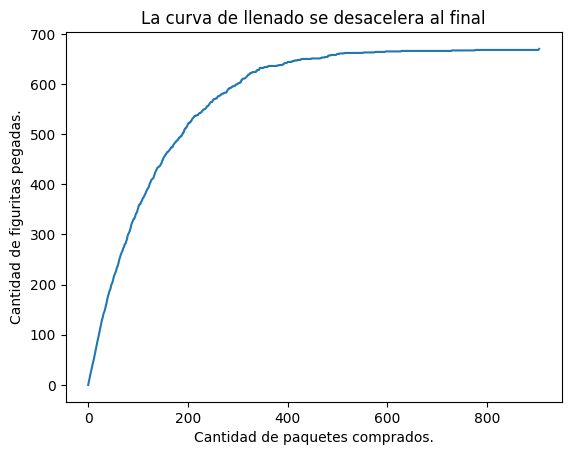

In [14]:
graficar_historia(670, 5)

In [15]:
# EJERCICIO 5.20 PROBABILIDAD DE COMPLETAR EL ALBUM CON 850 PAQUETES

def prob_completar_album(n_repeticiones, figus_total, figus_paquete, paq_lim):
    '''
    ESTIMA LA PROBABILIDAD DE COMPLETAR EL ALBUM CON HASTA UN NÚMERO LÍMITE DE PAQUETES
    DA ENTRE 20 Y 35%
    '''
    paquetes = [cuantos_paquetes(figus_total, figus_paquete) for i in range(n_repeticiones)]
    n_paquetes_hasta_llenar = np.array(paquetes)
    np.save('paquetes.npy', n_paquetes_hasta_llenar)
    # SUMA LA CANTIDAD DE VECES QUE APARECEN NÚMEROS MENORES O = QUE EL PAQ_LIM PROPUESTO
    prob = (n_paquetes_hasta_llenar <= paq_lim).sum () / n_repeticiones
    prob_90 = np.percentile(n_paquetes_hasta_llenar, 90)   # calcula el percentil 90, o sea, la probabilidad del 90%


    return prob, prob_90


In [16]:
# EJERCICIO 5.21 PLOTEAR HISTOGRAMA DE LLENADO DE ALBUM

def plotear_paquetes_para_completar_album(n_repeticiones):
    '''
    Dibuja un histograma con la frecuencia en que aparece la cantidad de paquetes
    para completar el álbum de figuritas.
    '''
    paquetes = np.load('paquetes.npy')
    plt.figure()
    plt.hist(paquetes, bins = 50, color = 'magenta')
    plt.xlabel('Paquetes de Figuritas ')
    plt.ylabel('Cantidad de repeticiones')
    plt.title(f'Distribución de paquetes para llenar el Álbum (n = {n_repeticiones} repeticiones)', loc = 'center')
    plt.savefig('paquetes.png', dpi = 300)
    plt.show()
    plt.close()

    return


In [17]:
n_repeticiones = 1000
figus_total = 670
figus_paquete = 5
paq_lim = 850
n_personas = 5

In [18]:
# EJERCICIO 5.22 ESTIMAR CUÁNTOS PAQUETES PARA TENER 90% DE PROBABILIDAD DE LLENAR EL ÁLBUM
    # Para tener 90% probabilidad de llenar el álbum hay que comprar 1164 paquetes

prob_90 = prob_completar_album(n_repeticiones, figus_total, figus_paquete, paq_lim)[1]
print(f'Para tener 90% probabilidad de llenar el álbum hay que comprar {round(prob_90)} paquetes')


Para tener 90% probabilidad de llenar el álbum hay que comprar 1154 paquetes


In [22]:
prob_completar_album_850=prob_completar_album(n_repeticiones, figus_total, figus_paquete, paq_lim)[0]
print(f'La probabilidad de completar el album comprando hasta 850 paquetes de figus es de {round(100 * prob_completar_album_850,2)}%')

La probabilidad de completar el album comprando hasta 850 paquetes de figus es de 31.5%


In [19]:
# EJERCICIO 5.23 sUPONER QUE NO HAY FIGUS REPETIDAS EN LOS PAQUETES

def comprar_paquete_sin_repes(figus_total, figus_paquete):
    '''
    Tomo una muestra de k figuritas (k es el tamaño del paquete) de la cantidad
    total de figuritas, que es figus, una lista con 670 elementos numerados.
    La muestra que tomo es SIN REPOSICIÓN, para no tener figuritas repetidas en
    los paquetes.
    Por eso uso random.sample
    K es 5, la cantidad de figus x paquete.
    '''
    figus = [i+1 for i in range(figus_total)]
    figus_compradas = random.sample(figus, k = figus_paquete)

    return figus_compradas

def cuantos_paquetes_sin_repes(figus_total, figus_paquete):
    '''
    Dado el tamaño del álbum (figus_total), genere un álbum nuevo, simule su
    llenado y devuelva la cantidad de PAQUETES de figuritas que se debieron
    comprar para completarlo.
    '''
    compras = 0
    album = crear_album(figus_total)

    while album_incompleto(album) == True:
        paquete_comprado = comprar_paquete_sin_repes(figus_total, figus_paquete)
        compras += 1
        for figu in paquete_comprado:
            album[figu -1] += 1

    return compras

def experimento_figus_sin_repes(n_repeticiones, figus_total, figus_paquete):
    '''
    RESULTADO OBTENIDO
    Haciendo 100 repeticiones, para llenar un album de 670 figus,
    hay que comprar un promedio de 959 de paquetes de figuritas
    Haciendo 1000 repeticiones, para llenar un album de 670 figus,
    hay que comprar un promedio de 954 de paquetes de figuritas
    '''
    paquetes = [cuantos_paquetes_sin_repes(figus_total, figus_paquete) for i in range(n_repeticiones)]
    promedio_paquetes = np.mean(paquetes)

    return promedio_paquetes

def prob_completar_album_sin_rep(n_repeticiones, figus_total, figus_paquete, paq_lim):
    '''
    ESTIMA LA PROBABILIDAD DE COMPLETAR EL ALBUM CON HASTA UN NÚMERO LÍMITE DE PAQUETES
    DA ENTRE 20 Y 35%
    '''
    paquetes = [cuantos_paquetes_sin_repes(figus_total, figus_paquete) for i in range(n_repeticiones)]
    n_paquetes_hasta_llenar_sin_rep = np.array(paquetes)
    np.save('paquetes_sin_rep.npy', n_paquetes_hasta_llenar_sin_rep)
    # SUMA LA CANTIDAD DE VECES QUE APARECEN NÚMEROS MENORES O = QUE EL PAQ_LIM PROPUESTO
    prob = (n_paquetes_hasta_llenar_sin_rep <= paq_lim).sum ()/n_repeticiones
    prob_90 = np.percentile(n_paquetes_hasta_llenar_sin_rep, 90)   # calcula el percentil 90, o sea, la probabilidad del 90%

    return prob, prob_90


In [20]:
# EJERCICIO 5.23 SIN FIGUS REPETIDAS EN LOS PAQUETES
    # LAS PROBABILIDADES NO MEJORAN SIGNIFICATIVAMENTE
'''
    Haciendo 100 repeticiones, para llenar un album de 670 figus SIN REPES,
    hay que comprar un promedio de 980 de paquetes de figuritas
    La probabilidad de completar el album comprando hasta 850 paquetes de figus SIN REPES es de 29.0%
'''

promedio_sin_repes = experimento_figus_sin_repes(n_repeticiones, figus_total, figus_paquete)
prob_llenar_850_sin_rep = prob_completar_album_sin_rep(n_repeticiones, figus_total, figus_paquete, paq_lim)[0]

print(f'Haciendo {n_repeticiones} repeticiones, para llenar un album de {figus_total} figus SIN REPES,')
print(f'hay que comprar un promedio de {round(promedio_sin_repes)} de paquetes de figuritas')
print(f'La probabilidad de completar el album comprando hasta {paq_lim} paquetes de figus SIN REPES es de {round(100 * prob_llenar_850_sin_rep,2)}%')


Haciendo 1000 repeticiones, para llenar un album de 670 figus SIN REPES,
hay que comprar un promedio de 944 de paquetes de figuritas
La probabilidad de completar el album comprando hasta 850 paquetes de figus SIN REPES es de 30.5%


In [23]:
# EJERCICIO 5.24 COOPERAR VS COMPETIR

def crear_album_coop(figus_total):
    '''
    Creo el album de figuritas para los 'k' amigos
    Crea un np array del tamaño del album lleno de ceros
    '''
    album_de_1 = [0 for i in range(figus_total)]
    album = np.array(album_de_1)

    return album

def album_incompleto_coop(album, n_personas):
    '''
     Mira si el album está incompleto. Depende del n_personas que colabore.
     Si n_personas=5, estamos
     Si todos los números no son mayores o iguales que 5, dará True
     '''
    esta_incompleto = False
    five_up = (album[album>=n_personas])   # para que sea five_up, n_personas=5
    #print(len(album))
    #print(len(five_up))
    if not (len(five_up) == len(album)):
        esta_incompleto = True

    return esta_incompleto


def cooperacion_nper(figus_total, figus_paquete, n_personas):
    '''
    Dado el tamaño del álbum (figus_total), genere un álbum nuevo, simule su
    llenado y devuelva la cantidad de PAQUETES de figuritas que se debieron
    comprar para completarlo.
    AHORA SON n_personas ALBUMES, PORQUE LOS n_personas COOPERAN ENTRE SÍ
    '''
    compras = 0
    album = crear_album_coop(figus_total)

    while album_incompleto_coop(album, n_personas) == True:
        paquete_comprado = comprar_paquete(figus_total, figus_paquete)
        compras += 1
        for figu in paquete_comprado:
            album[figu -1] += 1

    return compras

def experimento_nper(n_repeticiones, figus_total, figus_paquete, n_personas):
    '''
    RESULTADO OBTENIDO
    En el caso en que cinco amigos cooperen para llenar el album de 670 figus:
    Haciendo 100 repeticiones, para llenar un album de 670 figus,
    hay que comprar un promedio de 403 de paquetes de figuritas X PERSONA

    '''
    paquetes = [cooperacion_nper(figus_total, figus_paquete, n_personas) for i in range(n_repeticiones)]
    compras = np.array(paquetes)
    promedio_compras_persona = np.mean(compras)/n_personas

    return promedio_compras_persona

# SE PUEDE CREAR UNA GRÁFICA PARA VER COMO EVOLUCIONA LA CANTIDAD DE PAQUETES VS LA CANTIDAD DE PERSONAS QUE COLABORAN

In [24]:
    # ESTRATEGIA COLABORATIVA
promedio_cooperacion = experimento_nper(n_repeticiones, figus_total, figus_paquete, n_personas)
print(f'En el caso en que cinco amigos cooperen para llenar el album de figuritas:')
print(f'Haciendo {n_repeticiones} repeticiones, para llenar un album de {figus_total} figus, ')
print(f'hay que comprar un promedio de {round(promedio_cooperacion)} de paquetes de figuritas X PERSONA')


En el caso en que cinco amigos cooperen para llenar el album de figuritas:
Haciendo 1000 repeticiones, para llenar un album de 670 figus, 
hay que comprar un promedio de 403 de paquetes de figuritas X PERSONA


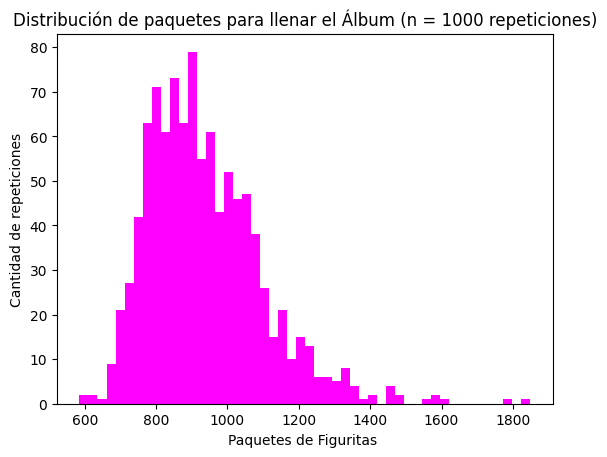

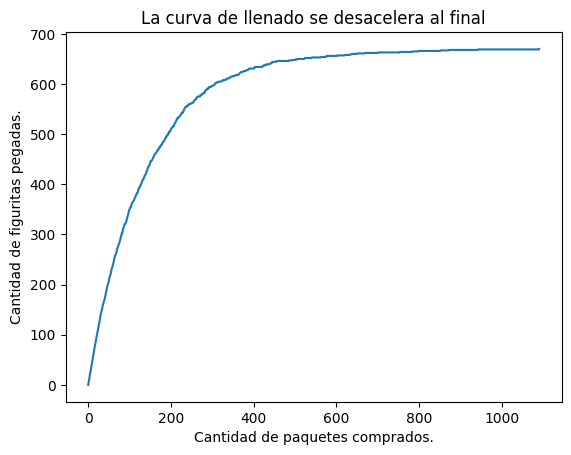

Haciendo 1000 repeticiones, para llenar un album de 670 figus, 
hay que comprar un promedio de 946 de paquetes de figuritas
La probabilidad de completar el album comprando hasta 850 paquetes de figus es de 33.3%


In [25]:
# ESTRATEGIA LOBO SOLITARIO (STANDALONE)
promedio = experimento_figus_670(n_repeticiones, figus_total, figus_paquete)
prob_llenar_850 = prob_completar_album(n_repeticiones, figus_total, figus_paquete, paq_lim)[0]
plotear_paquetes_para_completar_album(n_repeticiones)
graficar_historia(figus_total, figus_paquete)

print(f'Haciendo {n_repeticiones} repeticiones, para llenar un album de {figus_total} figus, ')
print(f'hay que comprar un promedio de {round(promedio)} de paquetes de figuritas')
print(f'La probabilidad de completar el album comprando hasta {paq_lim} paquetes de figus es de {round(100 * prob_llenar_850,2)}%')



In [ ]:
# Para obtener la curva que muestre la cantidad de paquetes necesarios para llenar el álbum
# usando la cooperación vs el número de personas que cooperen, hay que iterar cada simulación
# sobre el n_personas. Demora casi 40 minutos

nro_personas=range(1, 21)
paq_coop=[int(round(experimento_nper(n_repeticiones, figus_total, figus_paquete, persona),0)) for persona in nro_personas]


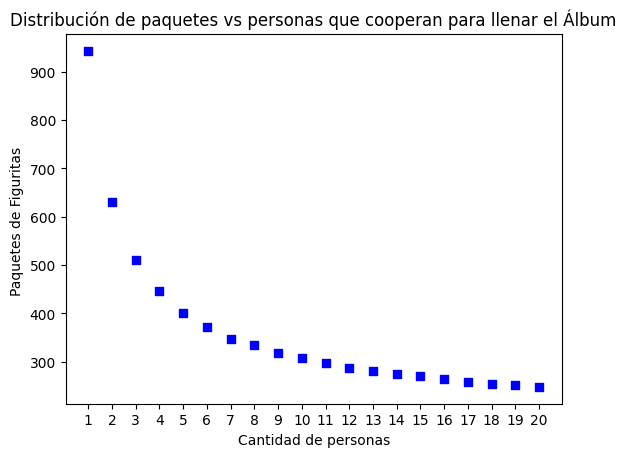

In [ ]:
plt.figure()
plt.scatter(nro_personas, paq_coop, color = 'blue', marker='s')
plt.xticks(nro_personas)
plt.xlabel('Cantidad de personas')
plt.ylabel('Paquetes de Figuritas ')
plt.title('Distribución de paquetes vs personas que cooperan para llenar el Álbum', loc = 'center')
#plt.savefig('paquetes_personas.png', dpi = 1200)
plt.show()
plt.close()